In [1]:
import numpy as np
import matplotlib.pyplot as plt

from beta_spectrum.components.fermi import FermiFunction
from beta_spectrum.components.phase_space import PhaseSpace
from beta_spectrum.components.finite_size import FiniteSizeL0
from beta_spectrum.components.finite_size import ChargeDistributionU
from beta_spectrum.components.screening import ScreeningCorrection
from beta_spectrum.components.exchange import ExchangeCorrection
from beta_spectrum.components.radiative import RadiativeCorrection

from beta_spectrum.constants import ME_MEV, ALPHA, HBAR_C_MEV_FM

from beta_spectrum.utils import W_to_T, T_to_W

In [2]:
endpoint_MeV = 0.2953
e_step_MeV = 0.001
Z_d = 44
Z_p = 43
A = 99

W0 = T_to_W(endpoint_MeV)
E = np.arange(e_step_MeV, endpoint_MeV, e_step_MeV)
W = T_to_W(E)

F = FermiFunction(Z_d, A)
Ph = PhaseSpace(W0=W0, m_nu=0)

L0 = FiniteSizeL0(Z_d, A)
U = ChargeDistributionU(Z_d, A)

S = ScreeningCorrection(FermiFunction(Z_p, A))
X = ExchangeCorrection(Z_p)

R = RadiativeCorrection(W0)
R_no_resum = RadiativeCorrection(W0, use_endpoint_resummation=False)

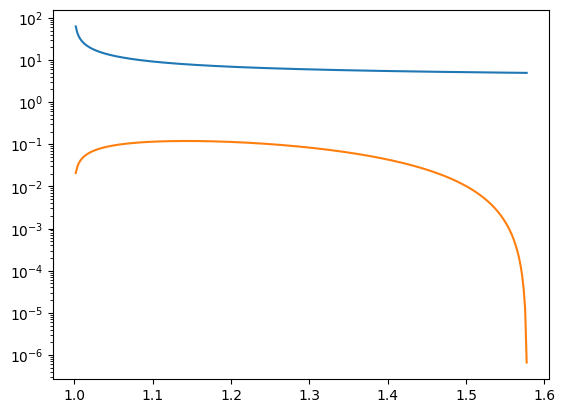

In [3]:
plt.plot(W, F(W))
plt.plot(W, Ph(W))
plt.yscale("log")
plt.show()

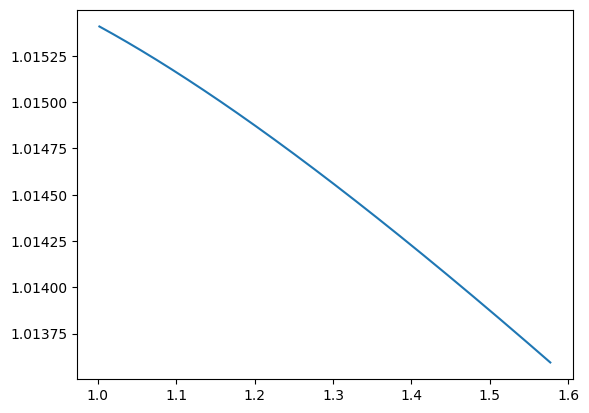

In [4]:
plt.plot(W, L0(W))

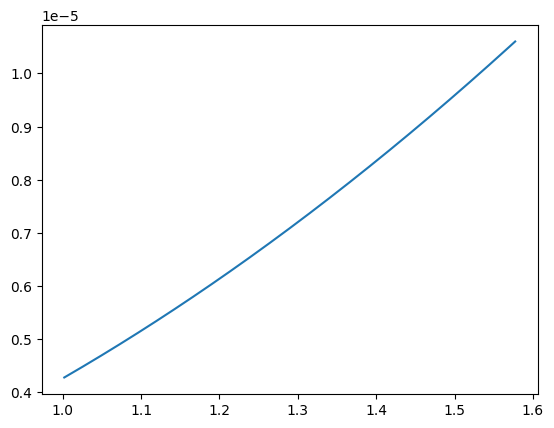

In [5]:
plt.plot(W, U(W) - 1)

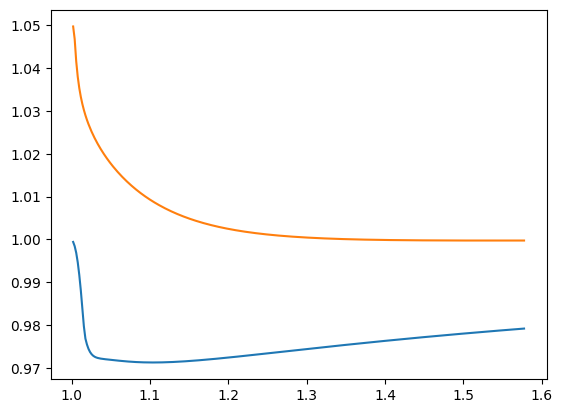

In [6]:
plt.plot(W, S(W))
plt.plot(W, X(W))

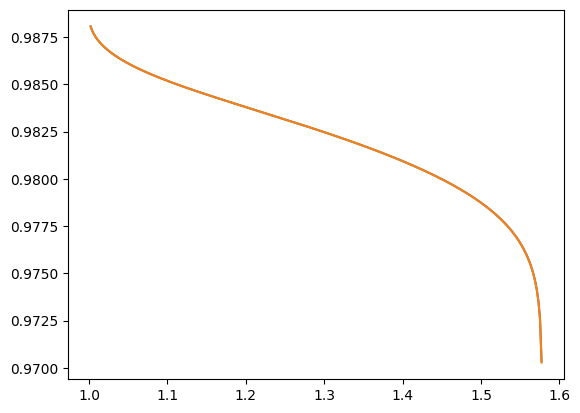

In [7]:
plt.plot(W, R(W))
plt.plot(W, R_no_resum(W))

(1.0005, 1.577887684505027)

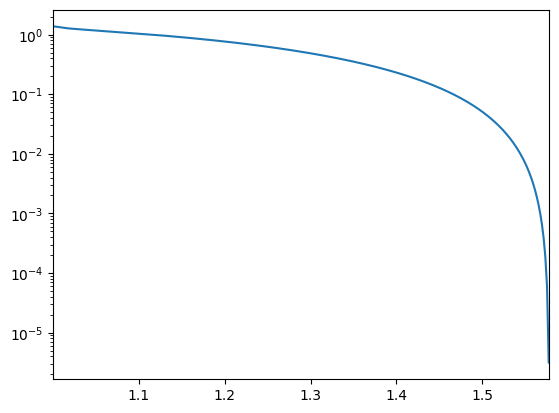

In [8]:
plt.plot(W, Ph(W)*F(W)*L0(W)*U(W)*S(W)*X(W)*R(W))
# plt.plot(W, Ph(W)*F(W)*L0(W)*U(W)*S(W)*X(W)*R_no_resum(W))
# plt.plot(W, Ph(W)*F(W))

YSCALE = "log"
plt.yscale(YSCALE)
if YSCALE == "linear":
    plt.ylim(0,)

plt.xlim(1.0005, W0)